# import Libraries 

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# LOad Dataset 

In [2]:
df = pd.read_csv("heart_disease_data.csv")

print(df.shape)
df.head()

(606, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,48,1,0,130,256,1,0,150,1,0.0,2,2,3,0
1,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
2,44,0,2,118,242,0,1,149,0,0.3,1,1,2,1
3,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
4,56,1,3,120,193,0,0,162,0,1.9,1,0,3,1


# separate features and targets 

In [3]:
X = df.drop("target", axis=1)

y = df["target"]

print(X.shape)
print(y.shape)

(606, 13)
(606,)


# Train test Split 

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(484, 13)
(122, 13)


# Feature Scaling 

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Logistics Regression Model

In [6]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

# Logistic Regression Evalution

In [7]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression Accuracy:",
      lr_accuracy)

Logistic Regression Accuracy: 0.8442622950819673


# confusion matrix

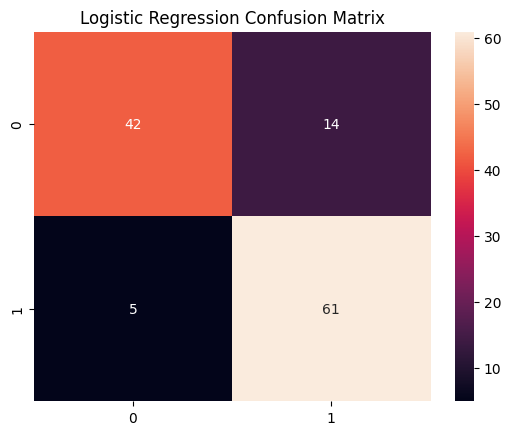

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Random forest model

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Random Forest Evalution

In [10]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:",
      rf_accuracy)

Random Forest Accuracy: 0.9836065573770492


# Random Forest Confusion Matrix

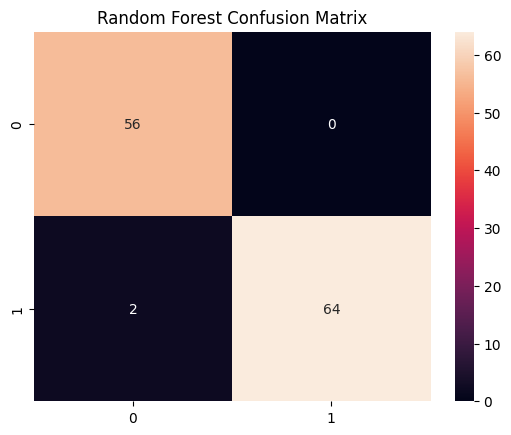

In [11]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Random Forest Confusion Matrix")
plt.show()

# Feature Importance 

In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,cp,0.134607
12,thal,0.120512
7,thalach,0.111136
11,ca,0.110626
9,oldpeak,0.110034
0,age,0.083584
4,chol,0.077691
3,trestbps,0.074117
8,exang,0.062457
10,slope,0.043650


# top 10 feature important plots 

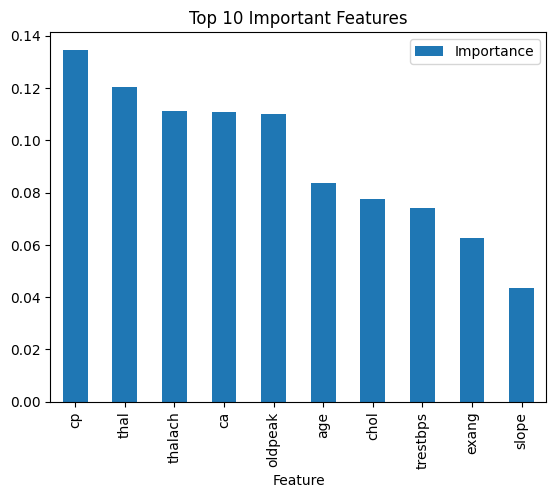

In [13]:
importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Important Features")
plt.show()

# saving the model

In [16]:
import joblib

joblib.dump(
    rf,
    "random_forest_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [17]:
importance.head(10)

,Feature,Importance
2,cp,0.134607
12,thal,0.120512
7,thalach,0.111136
11,ca,0.110626
9,oldpeak,0.110034
0,age,0.083584
4,chol,0.077691
3,trestbps,0.074117
8,exang,0.062457
10,slope,0.043650


## Model Performance

### Logistic Regression

* Accuracy: 84.43%

### Random Forest

* Accuracy: 98.36%

### Conclusion

Random Forest achieved the highest prediction accuracy and was selected as the final model for deployment. The model demonstrated excellent capability in identifying heart disease risk based on patient clinical attributes.


In [20]:
!pip install tensorflow


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [22]:
import sys

print(sys.version)

3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [24]:
model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(13,)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\Amrutha Reddy\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5013 - loss: 0.7968 - val_accuracy: 0.5361 - val_loss: 0.7391
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5736 - loss: 0.6737 - val_accuracy: 0.5876 - val_loss: 0.6476
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6693 - loss: 0.5996 - val_accuracy: 0.7010 - val_loss: 0.5820
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7855 - loss: 0.5364 - val_accuracy: 0.7835 - val_loss: 0.5301
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8114 - loss: 0.4791 - val_accuracy: 0.8041 - val_loss: 0.4887
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8372 - loss: 0.4278 - val_accuracy: 0.8144 - val_loss: 0.4534
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8630 - loss: 0.3871 - val_accuracy: 0.8144 - val_loss: 0.4229
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8708 - loss: 0.3530 - val_accuracy: 0.8247 - v

In [27]:
X_train_scaled

array([[-0.7220246 ,  0.67987914,  0.0423474 , ..., -0.6431797 ,
        -0.70247143, -0.51465024],
       [-1.16132052, -1.47084965,  1.01835422, ..., -0.6431797 ,
         0.2689462 , -0.51465024],
       [-0.7220246 ,  0.67987914, -0.93365942, ...,  0.96976836,
         1.24036383,  1.10282193],
       ...,
       [-0.94167256,  0.67987914,  1.01835422, ..., -0.6431797 ,
        -0.70247143, -0.51465024],
       [-0.1729047 ,  0.67987914,  1.01835422, ...,  0.96976836,
         2.21178146, -0.51465024],
       [ 0.70568715,  0.67987914, -0.93365942, ...,  0.96976836,
         0.2689462 ,  1.10282193]], shape=(484, 13))

In [28]:
loss, ann_accuracy = model.evaluate(
    X_test_scaled,
    y_test
)

print("ANN Accuracy:", ann_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9180 - loss: 0.3955
ANN Accuracy: 0.9180327653884888


In [29]:
model.save("heart_disease_ann_model.h5")

print("ANN Model Saved Successfully")

ANN Model Saved Successfully


In [30]:
print("ANN Accuracy:", ann_accuracy)

ANN Accuracy: 0.9180327653884888


# Model Comparison Report

## Performance Summary

| Model               | Accuracy |
| ------------------- | -------: |
| Logistic Regression |   84.43% |
| ANN                 |   91.80% |
| Random Forest       |   98.36% |

## Conclusion

Three predictive models were developed and evaluated for heart disease risk prediction. Random Forest achieved the highest accuracy of 98.36% and was selected as the final deployment model. The model demonstrated strong predictive capability while also providing feature importance insights for explainable healthcare analytics.


In [31]:
df.to_csv("heart_disease_dashboard.csv", index=False)

print("Dashboard Dataset Saved")

Dashboard Dataset Saved
